## Setup

In [ ]:
%pip install transformer_lens

In [ ]:
import math
import json

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, ActivationCache

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/activation patching/datasets/final_datasets

/content/drive/MyDrive/4 КУРС/нейросетки/activation patching/datasets/final_datasets


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = HookedTransformer.from_pretrained(
    "qwen3-1.7b",
    center_unembed=True,
    center_writing_weights=False,
    fold_ln=False,
    fold_value_biases=False,
    dtype="bfloat16",
    trust_remote_code=True,
).to(device)
print("Model loaded successfully.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model qwen3-1.7b into HookedTransformer
Moving model to device:  cuda
Model loaded successfully.


### Tools

In [ ]:
def get_batched_dataset(model, dataset, batch_size=8):
    items = list(dataset.values())
    num_total_samples = len(items)
    num_batches = math.floor(num_total_samples / batch_size)

    batches = []

    for i in range(num_batches):
        batch_items = items[i * batch_size : (i + 1) * batch_size]

        prefixes = [item["prefix"] for item in batch_items]
        prefix_tokens = model.to_tokens(prefixes)

        answer_token_lists = []
        for item in batch_items:
            correct_ids = model.to_tokens(" " + item["correct_verb"], prepend_bos=False)[0]
            incorrect_ids = model.to_tokens(" " + item["incorrect_verb"], prepend_bos=False)[0]

            answer_token_lists.append((correct_ids, incorrect_ids))

        batches.append({
            "prefix_tokens": prefix_tokens,
            "answer_token_lists": answer_token_lists,
            "metadata": batch_items
        })

    return batches

In [ ]:
def get_subject_indices(model, prefix, subject):
    """
    Finds exactly which token indices correspond to the subject string.
    """
    full_tokens = model.to_str_tokens(prefix)

    subj_tokens = model.to_str_tokens(subject)

    if full_tokens[0].startswith("<"):
        full_tokens = full_tokens[1:]
    if subj_tokens[0].startswith("<"):
        subj_tokens = subj_tokens[1:]

    subj_len = len(subj_tokens)
    for i in range(len(full_tokens) - subj_len + 1):
        if full_tokens[i : i + subj_len] == subj_tokens:
            return list(range(i, i + subj_len))

    return []

In [ ]:
def extract_subj(item):
    """Helps to get subject string based on language"""
    prefix = item['prefix']
    return prefix.split(" che")[0] if item['language'] == "italian" else prefix.split(" joka")[0].split(" jotka")[0]

In [ ]:
def get_clean_and_corr_batches(model, dataset_dict, batch_size=8):
    """Splits batches for clean and corrupted runs"""
    items = list(dataset_dict.values())

    grouped = {}
    for item in items:
        grouped.setdefault(item["item_id"], []).append(item)

    clean_items = []
    corr_items = []

    for i, (item_id, pair) in enumerate(grouped.items()):
        if len(pair) == 2:
            p1, p2 = pair

            if item_id % 2 == 0:
                src = p1 if p1["subject_number"] == "plural" else p2
                base = p1 if p1["subject_number"] == "singular" else p2
            else:
                src = p1 if p1["subject_number"] == "singular" else p2
                base = p1 if p1["subject_number"] == "plural" else p2

            clean_items.append(src)
            corr_items.append(base)

    clean_batches = get_batched_dataset(model, {str(i): x for i, x in enumerate(clean_items)}, batch_size)
    corr_batches = get_batched_dataset(model, {str(i): x for i, x in enumerate(corr_items)}, batch_size)

    return clean_batches, corr_batches

In [ ]:
def get_logit_diff(logits, answer_token_lists, mean=True):
    """Calculates logit difference"""
    if logits.dim() == 3:
        logits = logits[:, -1, :]

    diffs = []
    for i, (corr_ids, incorr_ids) in enumerate(answer_token_lists):
        corr_logit = logits[i, corr_ids].mean()
        incorr_logit = logits[i, incorr_ids].mean()
        diffs.append(corr_logit - incorr_logit)

    diffs = torch.stack(diffs)
    return diffs.mean() if mean else diffs

In [ ]:
class ActivationPatching:
	  def __init__(self, model, get_subject_indices_fn, extract_subj_fn, get_logit_diff_fn):
		    self.model = model
		    self.get_subject_indices = get_subject_indices_fn
		    self.extract_subj = extract_subj_fn
		    self.get_logit_diff = get_logit_diff_fn

    def run_verb_patching(self, clean_batch, corrupted_batch):
		    """Patches activations at the verb position"""
		    with torch.no_grad():
		        _, clean_cache = self.model.run_with_cache(clean_batch['prefix_tokens'])

			      # target the last token (where the model predicts the verb)
			      target_idx = -1
			      layer_results = []

			      for layer in range(self.model.cfg.n_layers):
				        hook_name = f"blocks.{layer}.hook_resid_pre"

				        def patch_to_verb_hook(act, hook):
					          for b_idx in range(act.shape[0]):
						            c_indices = self.get_subject_indices(
							          self.model,
							          clean_batch['metadata'][b_idx]['prefix'],
							          self.extract_subj(clean_batch['metadata'][b_idx])
						        )
						        if c_indices:
							         act[b_idx, target_idx, :] = clean_cache[hook_name][b_idx, c_indices[-1], :]
					          return act

				        patched_logits = self.model.run_with_hooks(
					      corrupted_batch['prefix_tokens'],
					      fwd_hooks=[(hook_name, patch_to_verb_hook)]
				        )

				        val = self.get_logit_diff(patched_logits, clean_batch['answer_token_lists']).item()
				        layer_results.append(val)

            return layer_results

    def normalize_verb_patch(self, layer_results, clean_ld, corr_ld):
		    denom = clean_ld - corr_ld

        # avoid division by zero if the model is totally confused
		    if abs(denom) < 1e-6:
			      return [0.0] * len(layer_results)
		    return [(val - corr_ld) / denom for val in layer_results]

    def process_batches(self, clean_batches, corr_batches):
		    """Runs activation patching on all batches"""
		    all_normalized_results = []

		    for b_idx in range(len(clean_batches)):
			      print(f"Processing Batch {b_idx + 1}/{len(clean_batches)}...")

			  clean_b = clean_batches[b_idx]
			  corr_b = corr_batches[b_idx]

			  # get baseline logit diff (denominator)
			  with torch.no_grad():
				    clean_logits = self.model(clean_b['prefix_tokens'])
				    corr_logits = self.model(corr_b['prefix_tokens'])

				    clean_ld = self.get_logit_diff(clean_logits, clean_b['answer_token_lists'], mean=True).item()
				    corr_ld = self.get_logit_diff(corr_logits, clean_b['answer_token_lists'], mean=True).item()

			      layer_raw_results = self.run_verb_patching(clean_b, corr_b)

            # normalize: (patched - corrupted) / (clean - corrupted)
			      normalized_layer_scores = self.normalize_verb_patch(layer_raw_results, clean_ld, corr_ld)
			      all_normalized_results.append(normalized_layer_scores)

			  return all_normalized_results

### Loading data

In [ ]:
with open("italian_test_dataset.json", "r", encoding="utf-8") as f:
    italian_json = json.load(f)

with open("finnish_test_dataset.json", "r", encoding="utf-8") as f:
    finnish_json = json.load(f)

In [ ]:
it_clean_batches, it_corr_batches = get_clean_and_corr_batches(model, italian_json)
fi_clean_batches, fi_corr_batches = get_clean_and_corr_batches(model, finnish_json)

## Localization

In [ ]:
patcher = ActivationParching(model, get_subject_indices, extract_subj, get_logit_diff)

### Denoising

In [ ]:
print("Running Italian...")
it_denoising = patcher.process_batches(model, it_clean_batches, it_corr_batches)

Running Italian...
Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [ ]:
print("Running Finnish...")
fi_denoising = patcher.process_batches(model, fi_clean_batches, fi_corr_batches)

Running Finnish...
Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [ ]:
it_array = np.abs(np.array(it_denoising))
it_layer_scores = np.mean(it_array, axis=0)

it_peak_layer = np.argmax(it_layer_scores)
print(f"Detected Italian SVA Layer: {it_peak_layer+1}")

Detected Italian SVA Layer: 27


In [ ]:
fi_array = np.abs(np.array(fi_denoising))
fi_layer_scores = np.mean(fi_array, axis=0)

fi_peak_layer = np.argmax(fi_layer_scores)
print(f"Detected Finnish SVA Layer: {fi_peak_layer+1}")

Detected Finnish SVA Layer: 22


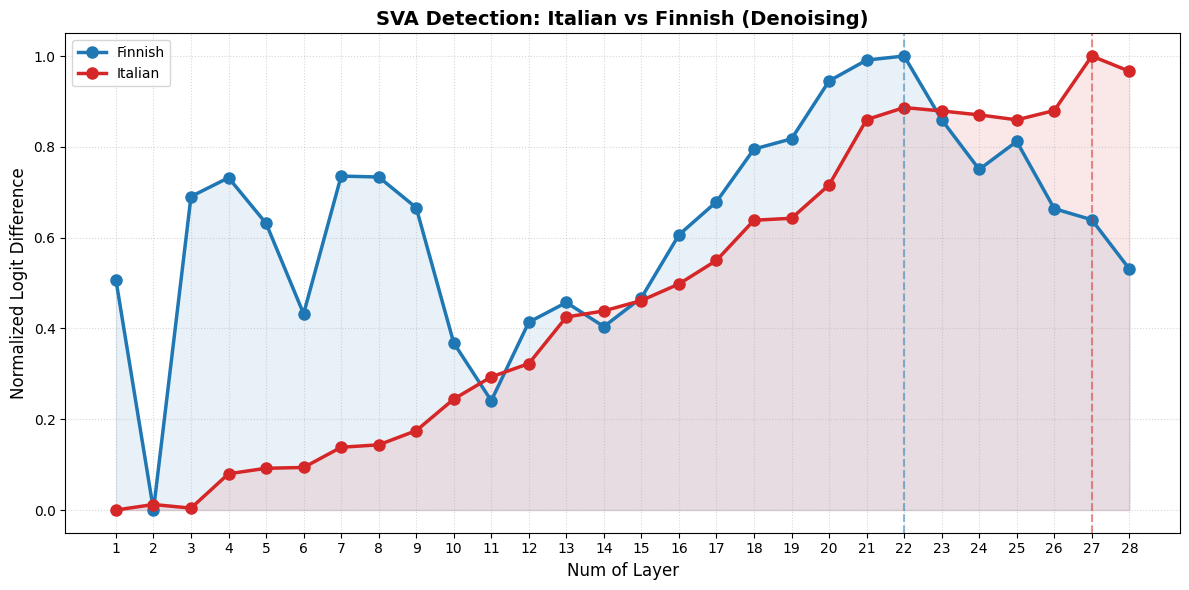

In [ ]:
it_mag = np.mean(np.abs(it_denoising), axis=0)
fi_mag = np.mean(np.abs(fi_denoising), axis=0)

it_norm = (it_mag - it_mag.min()) / (it_mag.max() - it_mag.min())
fi_norm = (fi_mag - fi_mag.min()) / (fi_mag.max() - fi_mag.min())

plt.figure(figsize=(12, 6))

# plot Finnish
plt.plot(range(1, len(fi_norm) + 1), fi_norm, label="Finnish",
         color='#1f77b4', marker='o', linewidth=2.5, markersize=8)
plt.fill_between(range(1, len(fi_norm) + 1), fi_norm, color='#1f77b4', alpha=0.1)

# plot Italian
plt.plot(range(1, len(it_norm) + 1), it_norm, label="Italian",
         color='#d62728', marker='o', linewidth=2.5, markersize=8)
plt.fill_between(range(1, len(it_norm) + 1), it_norm, color='#d62728', alpha=0.1)

plt.axvline(np.argmax(fi_norm)+1, color='#1f77b4', linestyle='--', alpha=0.5)
plt.axvline(np.argmax(it_norm)+1, color='#d62728', linestyle='--', alpha=0.5)

plt.title("SVA Detection: Italian vs Finnish (Denoising)", fontsize=14, fontweight='bold')
plt.xlabel("Num of Layer", fontsize=12)
plt.ylabel("Normalized Logit Difference", fontsize=12)
plt.xticks(range(1, 29))
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
it_norm

array([0.        , 0.01215078, 0.00419536, 0.0798788 , 0.09198712,
       0.09373805, 0.13828717, 0.14359363, 0.17479047, 0.24434887,
       0.29328989, 0.32252025, 0.42515052, 0.43859608, 0.461453  ,
       0.49792041, 0.54983641, 0.63834503, 0.64262392, 0.71605731,
       0.85997539, 0.88654855, 0.87901624, 0.87039077, 0.85947659,
       0.87996333, 1.        , 0.9664399 ])

In [ ]:
fi_norm

array([0.50676948, 0.        , 0.69057208, 0.73198956, 0.63145777,
       0.43227395, 0.73557812, 0.73354909, 0.66604091, 0.36805259,
       0.24080803, 0.41374406, 0.45717452, 0.40401183, 0.46761074,
       0.6061203 , 0.67897951, 0.79509595, 0.81759697, 0.94503448,
       0.99110524, 1.        , 0.85971687, 0.75023321, 0.81189729,
       0.66380093, 0.63934469, 0.53103221])

### Noising

In [ ]:
print("Running Italian...")
it_noising = patcher.process_batches(model, it_corr_batches, it_clean_batches)

Running Italian...
Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [ ]:
print("Running Finnish...")
fi_noising = patcher.process_batches(model, fi_corr_batches, fi_clean_batches)

Running Finnish...
Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [ ]:
it_array = np.abs(np.array(it_noising))
it_layer_scores = np.mean(it_array, axis=0)

it_peak_layer = np.argmax(it_layer_scores)
print(f"Detected Italian SVA Layer: {it_peak_layer+1}")

Detected Italian SVA Layer: 27


In [ ]:
fi_array = np.abs(np.array(fi_noising))
fi_layer_scores = np.mean(fi_array, axis=0)

fi_peak_layer = np.argmax(fi_layer_scores)
print(f"Detected Finnish SVA Layer: {fi_peak_layer+1}")

Detected Finnish SVA Layer: 20


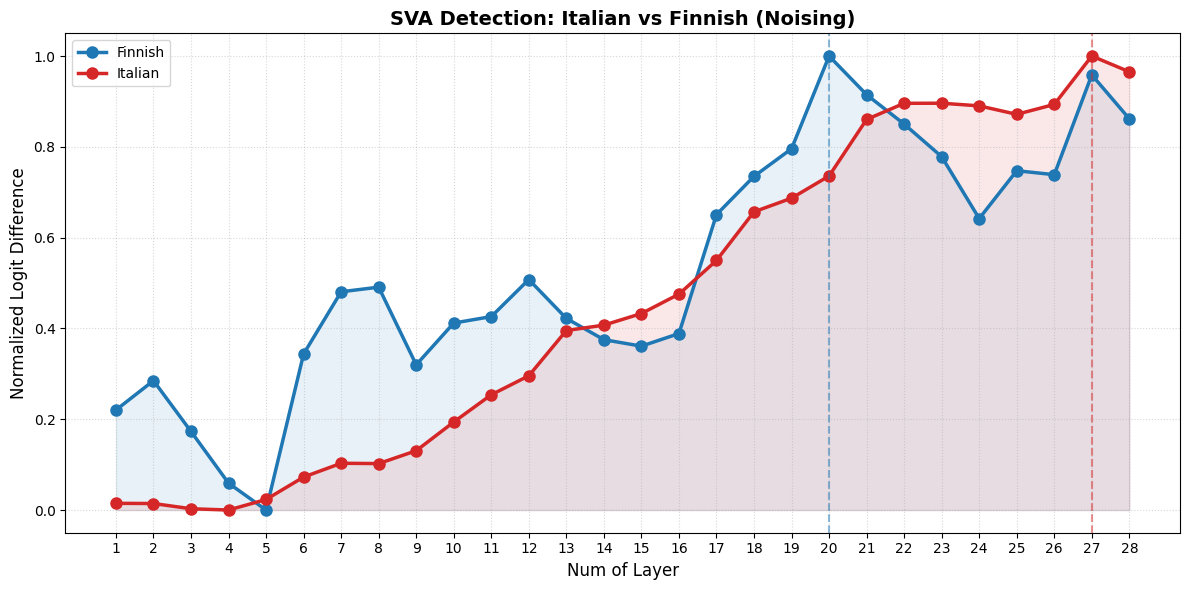

In [ ]:
it_mag = np.mean(np.abs(it_noising), axis=0)
fi_mag = np.mean(np.abs(fi_noising), axis=0)

it_norm = (it_mag - it_mag.min()) / (it_mag.max() - it_mag.min())
fi_norm = (fi_mag - fi_mag.min()) / (fi_mag.max() - fi_mag.min())

plt.figure(figsize=(12, 6))

# plot Finnish
plt.plot(range(1, len(fi_norm) + 1), fi_norm, label="Finnish",
         color='#1f77b4', marker='o', linewidth=2.5, markersize=8)
plt.fill_between(range(1, len(fi_norm) + 1), fi_norm, color='#1f77b4', alpha=0.1)

# plot Italian
plt.plot(range(1, len(it_norm) + 1), it_norm, label="Italian",
         color='#d62728', marker='o', linewidth=2.5, markersize=8)
plt.fill_between(range(1, len(it_norm) + 1), it_norm, color='#d62728', alpha=0.1)

plt.axvline(np.argmax(fi_norm)+1, color='#1f77b4', linestyle='--', alpha=0.5)
plt.axvline(np.argmax(it_norm)+1, color='#d62728', linestyle='--', alpha=0.5)

plt.title("SVA Detection: Italian vs Finnish (Noising)", fontsize=14, fontweight='bold')
plt.xlabel("Num of Layer", fontsize=12)
plt.ylabel("Normalized Logit Difference", fontsize=12)
plt.xticks(range(1, 29))
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
it_norm

array([0.01476376, 0.01433351, 0.00282082, 0.        , 0.02324841,
       0.07262605, 0.10301238, 0.10228762, 0.13065054, 0.19383643,
       0.2539128 , 0.29569544, 0.3954112 , 0.40722664, 0.43282221,
       0.47553416, 0.54970496, 0.65686891, 0.68689621, 0.73579824,
       0.86034092, 0.89589568, 0.89605096, 0.89026689, 0.87159547,
       0.89337511, 1.        , 0.96532012])

In [ ]:
fi_norm

array([0.2203141 , 0.28494466, 0.17300743, 0.05917971, 0.        ,
       0.34378271, 0.48073675, 0.49089439, 0.31993645, 0.41183911,
       0.42607837, 0.50771453, 0.42207865, 0.37523464, 0.3609784 ,
       0.38868077, 0.65076217, 0.7350138 , 0.79576126, 1.        ,
       0.9148524 , 0.85011761, 0.77834291, 0.64202759, 0.74739216,
       0.73864371, 0.95849003, 0.86173603])